In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

La maladie coronarienne, ou coronaropathie,est une maladie chronique touchant les arteres qui nourrissent le coeur (arteres coronaires). Elle est causee
par l'atherosclerose, soit une accumulation de plaques de cholesterol, qui retrecissent (stenose) ou bouchent les vaisseaux. cette obstruction reduit l'apport d'oxygene, provoquant douleurs thoraciques (angine), fatigue et, en cas d'occlusion totale, un infarctus.
L'etude Framingham (Framingham Heart Study), debutee en 1948 dans le Massachusetts, est une recherche epidemologique fondamentale qui a identifie les principaux facteurs de risque cardiovasculaire (tabac, cholesterol, hypertension). Son score de risque permet d'evaluer la probablite d'un evenement cardiaque sur 10 ans.
Causes et facteurs de risque :
- Tabagisme
- Hypertenson arterielle
- Hypercholesterolemie : Exces de mauvais cholesterol (LDL)
- Diabete
- Heredite, age et sexe masculin (les femmes sont egalement concernees souvent plus tard).

## Description de la base de donnees
- male : indique si le patient est un homme (1) ou une femme (0).
- age : Age du patient en annees.
- education : niveau d'etucation du patient (1 a 4).
- currentSmoker :Indique si le patient est un fumeur actuel (1) ou non (0).
- cigPerDay : Nombre de cigarettes fumees par jour.
- BPMeds : Indique si le patient prend des medicaments contre l'hypertension (1) ou non (0).
- prevalentStroke : Indique si le patient a des antecedents d'AVC (1) ou non (0).
- prevalentHyp : Indique si le patient a des antecedents d'hypertension (1) ou non (0).
- diabetes : Indique si le patient est diabetique (1) ou non (0).
- totChol :Taux de cholesterol total du patient.
- sysBP : Pression arterielle systolique du patient.
- diaBP : Pression arterielle diastolique du patient.
- BMI : indice de masse corporelle du patient.
- heartRate : frequence cardiaque du patient.
- glucose : Taux de glucose du patient.
- TenYearCHD : Indique le risque a 10 ans de maladie coronarienne (1) ou non (0).

In [2]:
#Importation du fichier originale
df = pd.read_csv("..\\data\\framingham_heart_study.csv")

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.shape

(4240, 16)

In [5]:
df.rename(columns = {'male':'gender'}, inplace = True)

In [6]:
df.columns

Index(['gender', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [7]:
df.dtypes

gender               int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [8]:
# Presence de doublons
df.duplicated().sum()

np.int64(0)

# Formatage des donnees 

In [9]:
df['gender'].replace({0:'female', 1:'male'}, inplace = True)
df['education'].replace({1.0 : 'level 1', 2.0 : 'level 2', 3.0 : 'level 3', 4.0 : 'level 4'}, inplace = True)
df['currentSmoker'].replace({0: 'No', 1 : 'Yes'}, inplace = True)
df['BPMeds'].replace({1.0:'Yes', 0.0:'No'}, inplace = True)
df['prevalentStroke'].replace({0: 'No', 1 : 'Yes'}, inplace = True)
df['prevalentHyp'].replace({0: 'No', 1 : 'Yes'}, inplace = True)
df['diabetes'].replace({0: 'No', 1 : 'Yes'}, inplace = True)

In [10]:
df.head()

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,male,39,level 4,No,0.0,No,No,No,No,195.0,106.0,70.0,26.97,80.0,77.0,0
1,female,46,level 2,No,0.0,No,No,No,No,250.0,121.0,81.0,28.73,95.0,76.0,0
2,male,48,level 1,Yes,20.0,No,No,No,No,245.0,127.5,80.0,25.34,75.0,70.0,0
3,female,61,level 3,Yes,30.0,No,No,Yes,No,225.0,150.0,95.0,28.58,65.0,103.0,1
4,female,46,level 3,Yes,23.0,No,No,No,No,285.0,130.0,84.0,23.10,85.0,85.0,0


# Gestion des valeurs manquantes

In [11]:
# Presence de donnees manquantes
df.isnull().sum()

gender               0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [12]:
#Nombre de donnees manquantes
nombre_valeurs_manquantes = df.isnull().sum().sum()
nombre_valeurs_manquantes

np.int64(645)

In [13]:
#Pourcentage de donnees manquantes
nombre_valeurs_manquantes / len (df) * 100

# On constate que les valeurs manquantes ici represente 15% du dataset, nous ne pouvons donc pas les supprimer. Nous optons pour une imputation

np.float64(15.212264150943398)

In [14]:
df.describe(include = 'number').T

,count,mean,std,min,25%,50%,75%,max
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.00,128.0,144.00,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.00,82.0,90.00,142.5
BMI,4221.0,25.800801,4.079840,15.54,23.07,25.4,28.04,56.8
heartRate,4239.0,75.878981,12.025348,44.00,68.00,75.0,83.00,143.0
glucose,3852.0,81.963655,23.954335,40.00,71.00,78.0,87.00,394.0
TenYearCHD,4240.0,0.151887,0.358953,0.00,0.00,0.0,0.00,1.0


In [15]:
df.describe(include = 'object').T

,count,unique,top,freq
gender,4240,2,female,2420
education,4135,4,level 1,1720
currentSmoker,4240,2,No,2145
BPMeds,4187,2,No,4063
prevalentStroke,4240,2,No,4215
prevalentHyp,4240,2,No,2923
diabetes,4240,2,No,4131


In [16]:
# On constate que aucune donnee ne suit une loi normale, nous allons donc imputer les valeurs masnquantes par modelisation

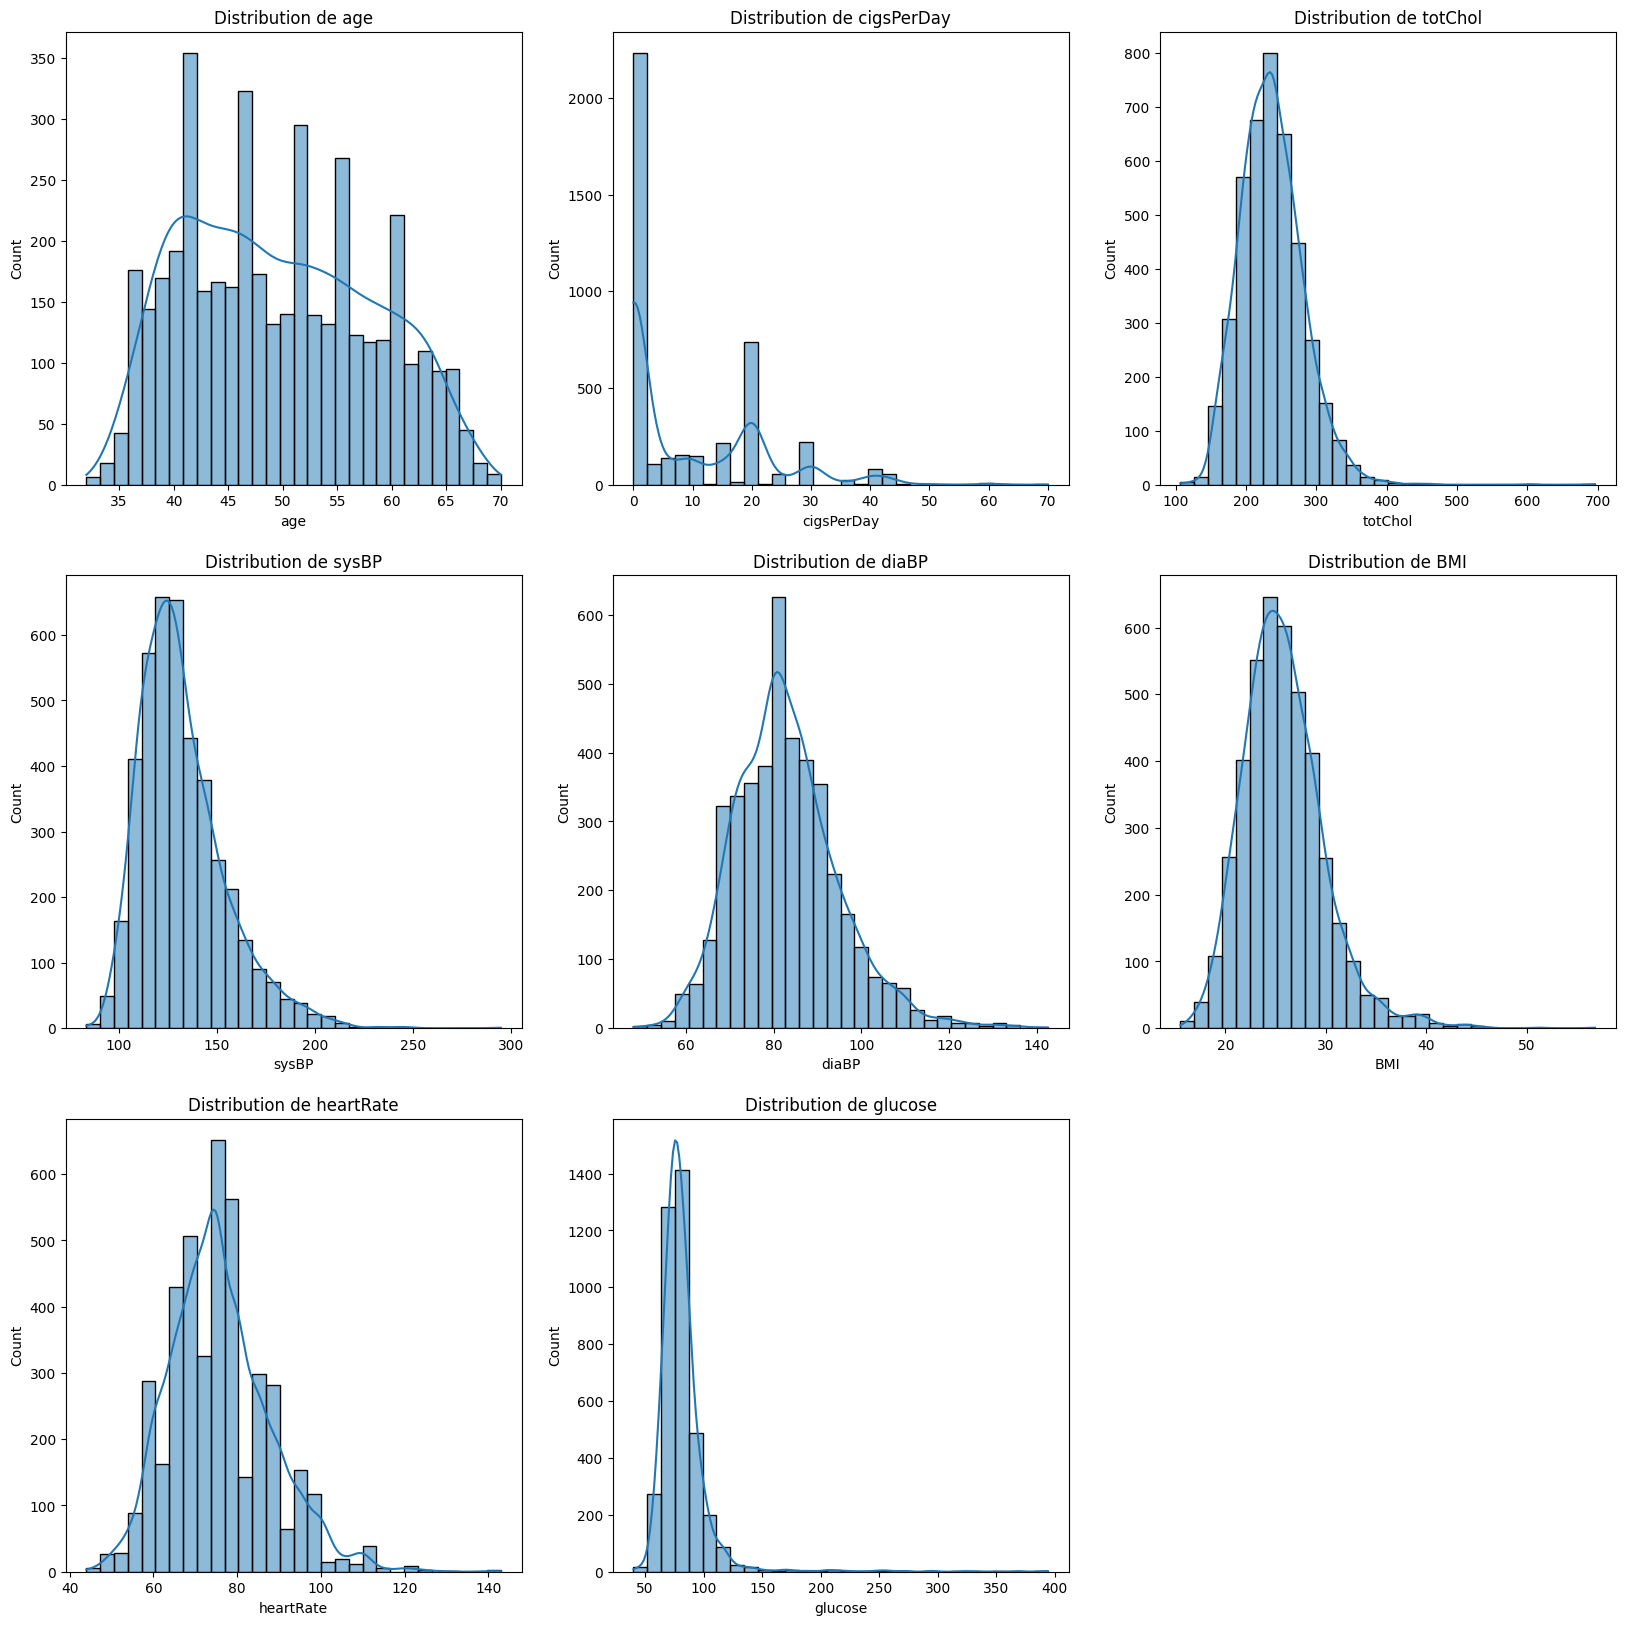

In [17]:
plt.figure(figsize = (20, 20))
for i, col in enumerate(df.select_dtypes(include = 'number').columns.drop('TenYearCHD')) :
    plt.subplot(3, 3, i+1)
    plt.title(f'Distribution de {col}')
    sns.histplot(data = df, x = col, bins = 30, kde = True)

In [18]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

colonnes_avec_na = []

# Créer un imputer IterativeImputer avec une stratégie de 'mean'
imputer = IterativeImputer(max_iter=10, random_state=0, sample_posterior=True, initial_strategy= 'median')
colonnes_numeriques_a_traiter = ['glucose', 'heartRate', 'BMI', 'totChol', 'cigsPerDay']
# Imputer les colonnes 'total_protein', 'rectal_temp' et 'pulse' de la DataFrame df
df[colonnes_numeriques_a_traiter] = pd.DataFrame(imputer.fit_transform(df[colonnes_numeriques_a_traiter]), columns = colonnes_numeriques_a_traiter)

In [19]:
df.isnull().mean().sum()
# il reste moins de 5% de donnees manquantes dans notre datase. Pour eviter d'introduire plus de biais nous allons les supprimer

np.float64(0.03726415094339623)

In [20]:
df.dropna(inplace = True)

In [21]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
df.shape

(4082, 16)

# Gestion des valeurs aberrantes 

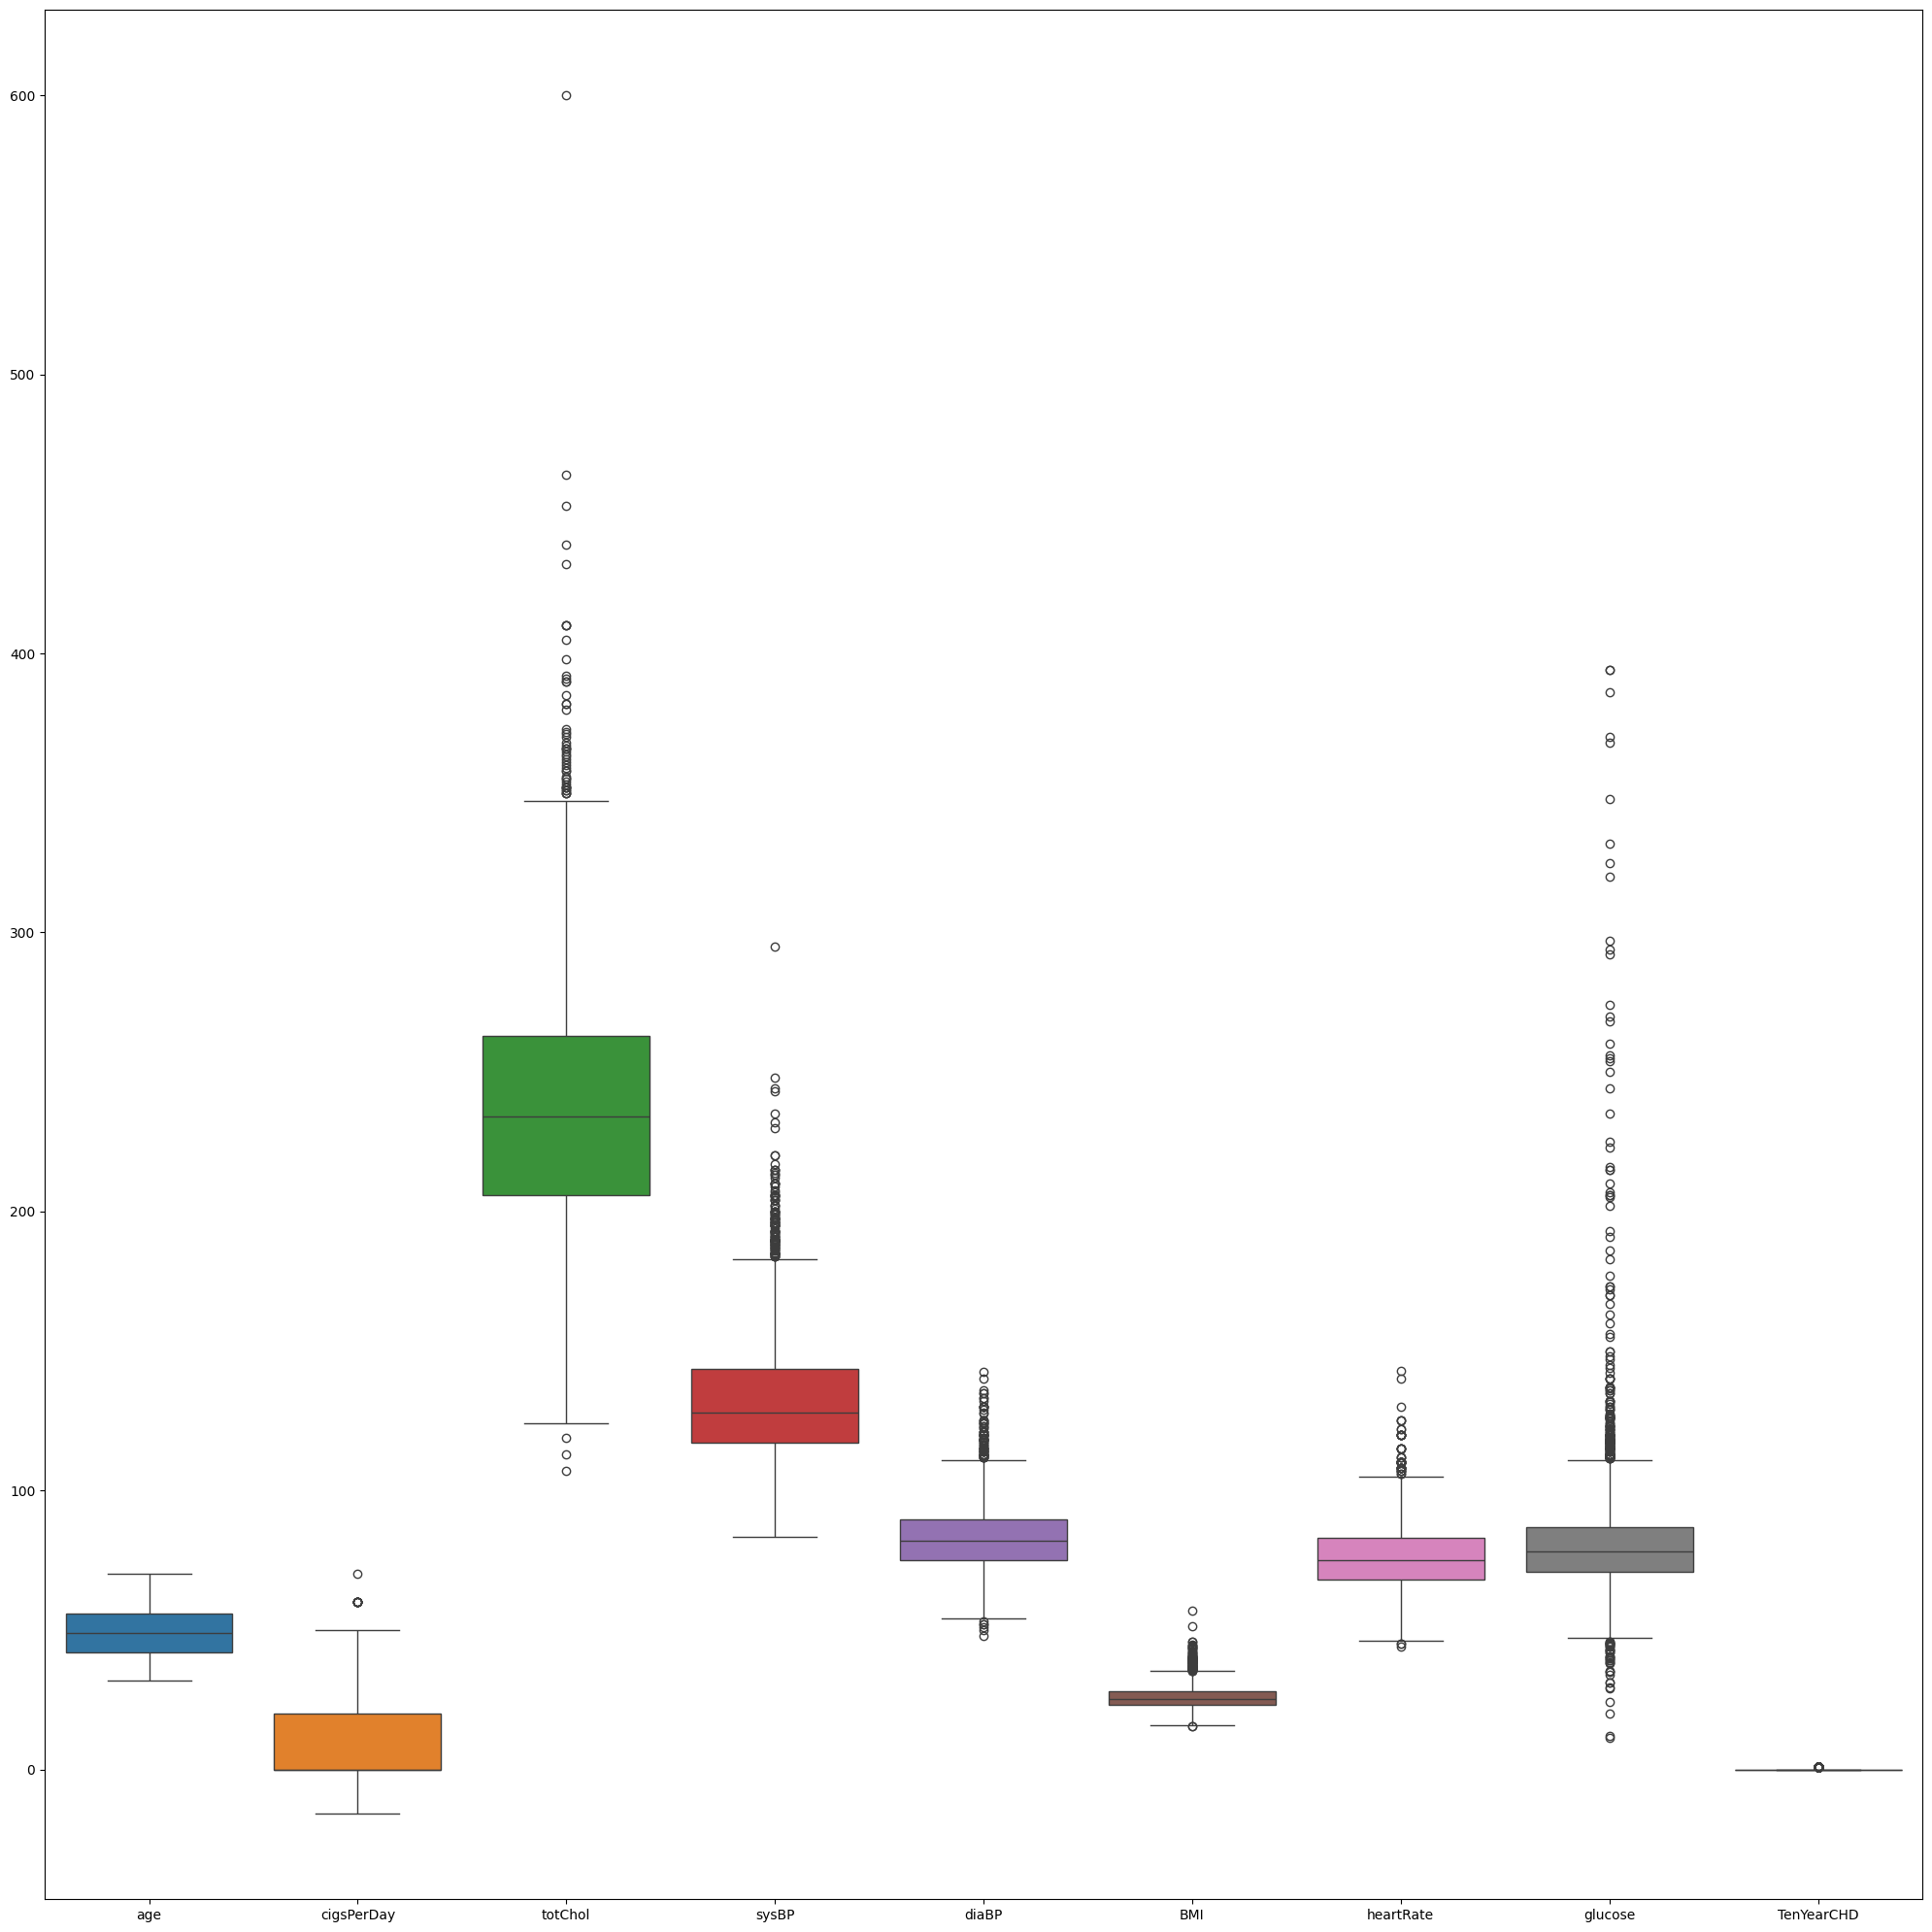

In [23]:
plt.figure(figsize = (20, 20))
sns.boxplot(df)
plt.tight_layout()

In [24]:
#Variable qui va contenir le nombre de valeurs aberrantes
result = set()
def nombre_outliers(data) :
    """
    Fonction qui permet d'obtenir le nombre de valeur aberrante
    """
    for col in data.select_dtypes('number').columns.drop(['TenYearCHD', 'age']) : 
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        result.update(outliers.index)

nombre_outliers(df)
len(result) # On a au totale 567 valeurs aberrantes, qui est un nombre important pour notre jeu de donnees.

567

<Axes: >

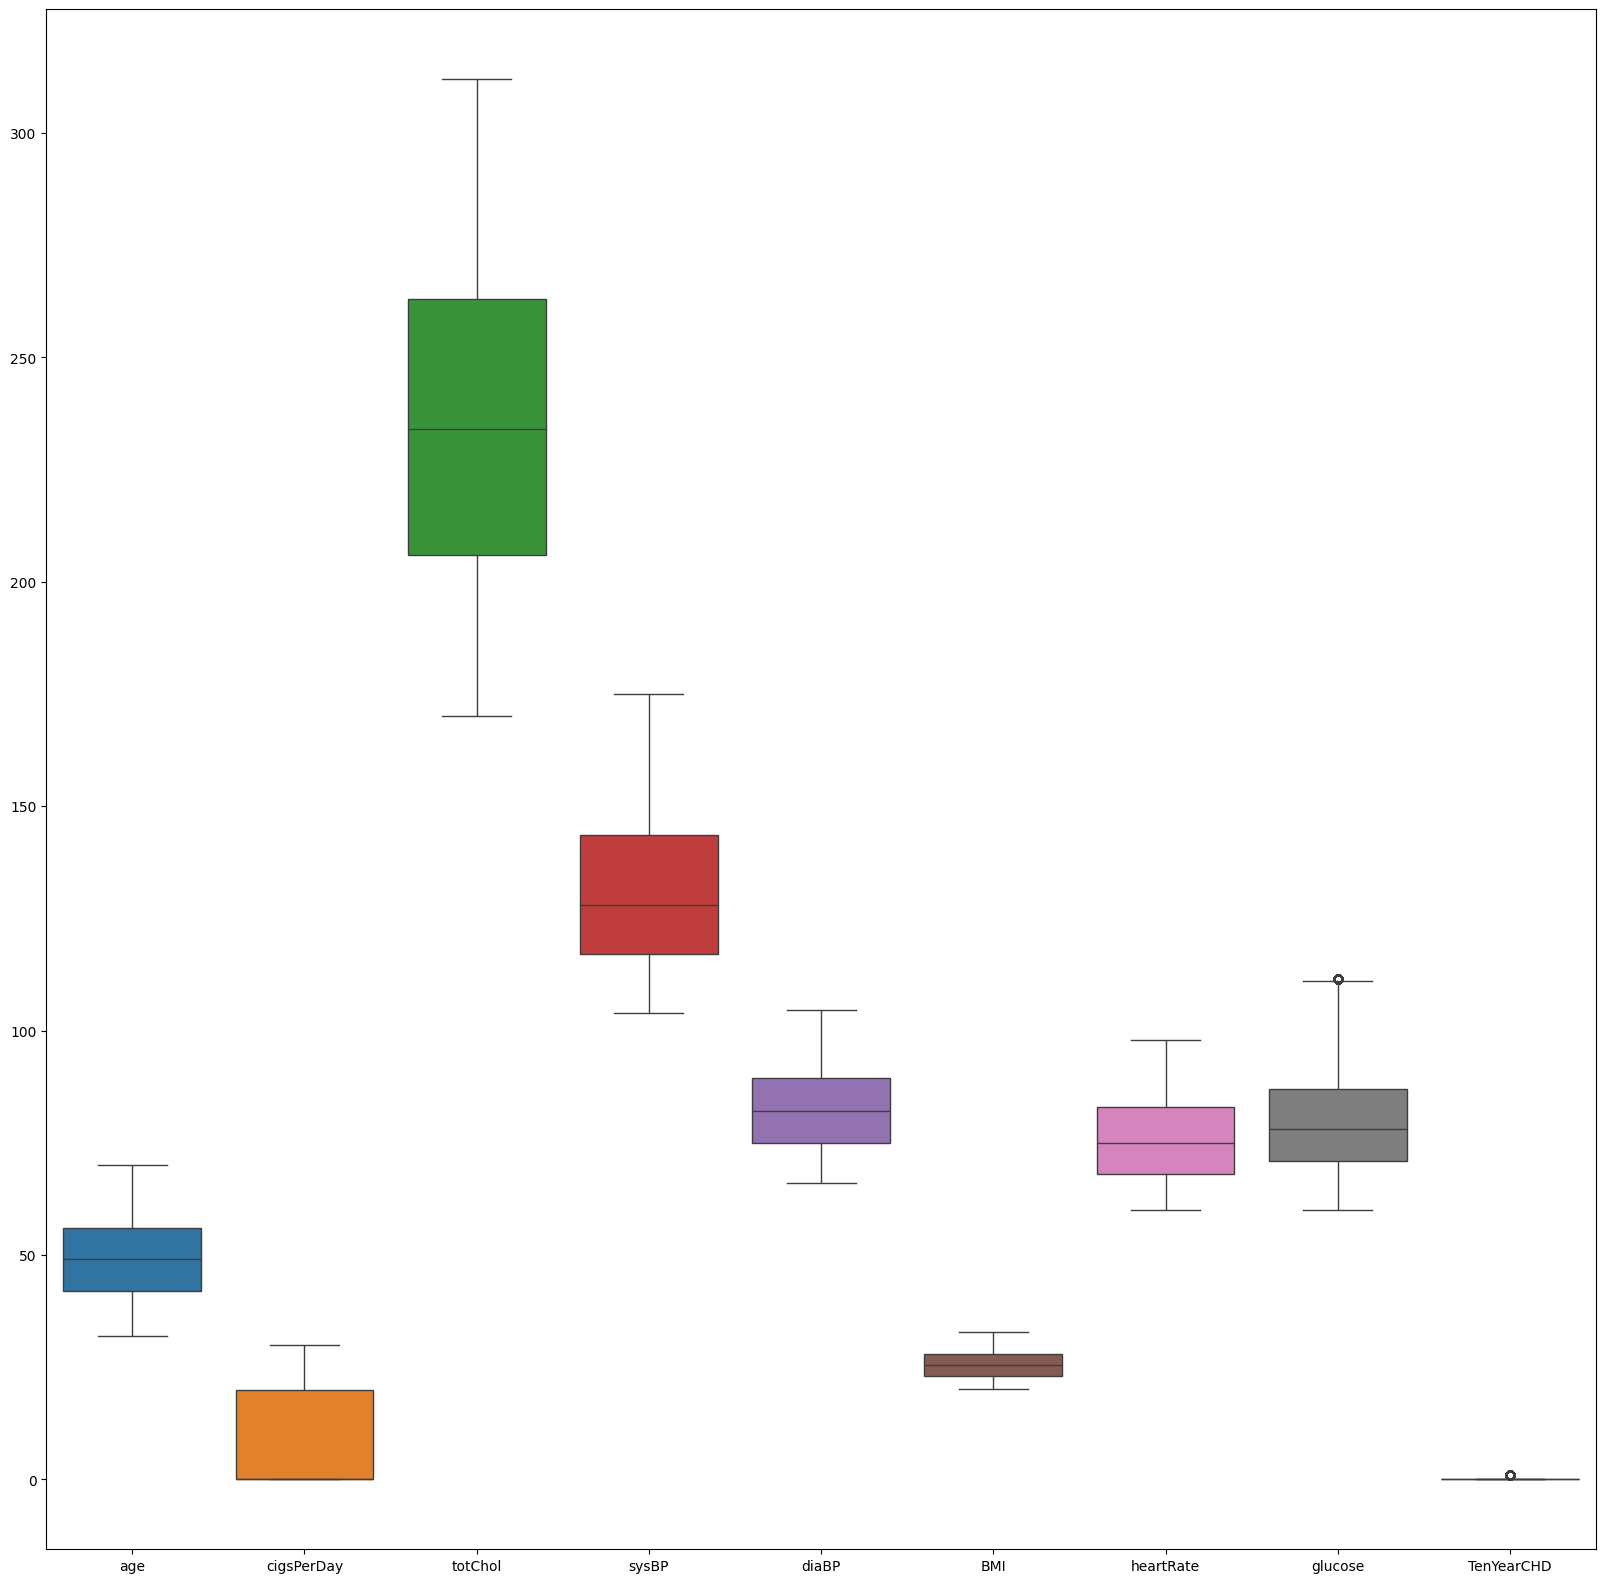

In [25]:
#Limitation des valeurs extremes
def limite_outliers(data) :
    """
    Fonction qui permet de limiter les valeurs  aberrantes
    """
    for col in data.select_dtypes('number').columns.drop(['TenYearCHD', 'age']) : 
        first_percent = data[col].quantile(0.05)
        second_percent = data[col].quantile(0.95)
        data[col] = data[col].clip(lower = first_percent, upper = second_percent)

limite_outliers(df)
plt.figure(figsize = (20, 20))
sns.boxplot(df)

# Ingenieurie des cateristiques

In [26]:
# Ici nous allons juste sauvegarder nos donnees traitees

df.to_csv('..\\data\\data_exploration.csv', index = False)